<a href="https://colab.research.google.com/github/hiten4/Day20PM/blob/main/DAy_20_PM_Part_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math


In [3]:

np.random.seed(42)
data = np.random.normal(50, 10, 1000)


def mean(data):
    total = 0
    count = 0
    for x in data:
        total += x
        count += 1
    return total / count



def variance(data):
    m = mean(data)
    total = 0
    count = 0
    for x in data:
        total += (x - m) ** 2
        count += 1
    return total / count


def std_dev(data):
    return math.sqrt(variance(data))


m = mean(data)
v = variance(data)
s = std_dev(data)

print("Mean:", m)
print("Variance:", v)
print("Std Dev:", s)

Mean: 50.19332055822327
Variance: 95.79049897315171
Std Dev: 9.787262077473542


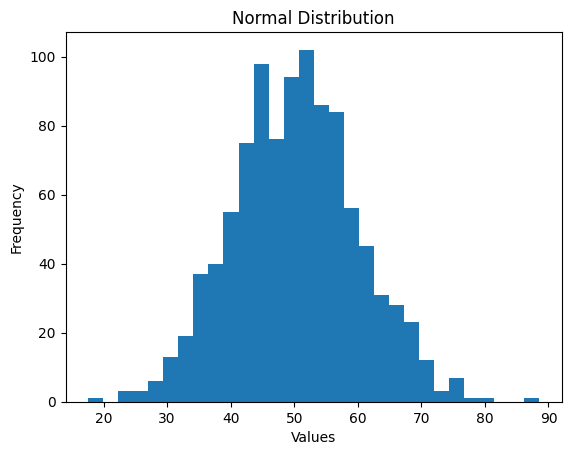

In [4]:

plt.hist(data, bins=30)
plt.title("Normal Distribution")
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.show()

# 2. Z-score conversion

In [5]:
def z_score(x, mean, std):
    return (x - mean) / std


z_data = []

for x in data:
    z_data.append(z_score(x, m, s))

z_data = np.array(z_data)

print("Z Mean:", mean(z_data))
print("Z Std:", std_dev(z_data))



Z Mean: -1.5523138330308938e-15
Z Std: 0.9999999999999999


# 3. Student marks analysis


In [6]:
marks = [45, 78, 88, 92, 67, 54, 73, 81]

m_marks = mean(marks)
median_marks = sorted(marks)[len(marks)//2]
v_marks = variance(marks)
s_marks = std_dev(marks)

print(m_marks, median_marks, v_marks, s_marks)

outliers = []
for x in marks:
    z = (x - m_marks) / s_marks
    if abs(z) > 2:
        outliers.append(x)

print("Outliers:", outliers)


72.25 78 231.4375 15.213070038621396
Outliers: []



# 4. One-sample hypothesis test (Z-test)

In [7]:
mu = 50

z_stat = (m - mu) / (s / math.sqrt(len(data)))

print("Z-statistic:", z_stat)


critical = 1.96

if abs(z_stat) > critical:
    print("Reject H0")
else:
    print("Fail to reject H0")


Z-statistic: 0.6246213472997505
Fail to reject H0


# 5. Simulation for false positive rate

In [8]:

count_reject = 0
iterations = 1000

for _ in range(iterations):
    sample = np.random.normal(50, 10, 100)

    m_s = mean(sample)
    s_s = std_dev(sample)

    z = (m_s - 50) / (s_s / math.sqrt(len(sample)))

    if abs(z) > 1.96:
        count_reject += 1

false_positive_rate = count_reject / iterations

print("False Positive Rate:", false_positive_rate)

False Positive Rate: 0.063
